Copyright (c) MONAI Consortium  
Licensed under the Apache License, Version 2.0 (the "License");  
you may not use this file except in compliance with the License.  
You may obtain a copy of the License at  
    http://www.apache.org/licenses/LICENSE-2.0  
Unless required by applicable law or agreed to in writing, software  
distributed under the License is distributed on an "AS IS" BASIS,  
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.  
See the License for the specific language governing permissions and  
limitations under the License.  

# MONAI 3D Segmentation with PyTorch 2.0 Features

This tutorial shows how to use `torch.compile` with a segmentation model written in MONAI

NOTE:
`torch.compile` in PyTorch 2.0 requires a full CUDA installation. For CUDA 11.7, please refer to [the NVIDIA website](https://developer.nvidia.com/cuda-11-7-0-download-archive) for the installation guide.
    


## Set up environment

Below we install the latest nightly build of PyTorch and MONAI 0.9.0. For later MONAI versions, the new graph compiler in PyTorch is unable to recognize the `MetaTensor` type, which is a superset of the `torch.Tensor`, in the compilation pipeline.

In [1]:
!python -c "import pkg_resources; pkg_resources.require('torch>1.13'); import torch" || pip3 install numpy --pre torch[dynamo] --force-reinstall --extra-index-url https://download.pytorch.org/whl/nightly/cu117
!python -c "import pkg_resources; pkg_resources.require('monai==0.9.0'); import monai" || (pip3 uninstall -y monai && pip3 install monai[nibabel]==0.9.0)
!python -c "import matplotlib" || pip3 install matplotlib
!python -c "import tabulate" || pip3 install tabulate

## Set up imports

In [2]:
import os
import tempfile
from glob import glob

import nibabel as nib
import numpy as np
import torch
import matplotlib.pyplot as plt

import monai
from monai.data import ImageDataset, DataLoader, create_test_image_3d
from monai.transforms import (
    AddChannel,
    Compose,
    RandSpatialCrop,
    ScaleIntensity,
    EnsureType,
)

import warnings
warnings.filterwarnings("ignore", category=UserWarning) 

## Set up timing and training functions

For best accuracies, we use CUDA events and synchronization to measure the forward and backward propagations in training

In [3]:
def timed(fn):
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    start.record()
    result = fn()
    end.record()
    torch.cuda.synchronize()
    return result, start.elapsed_time(end) / 1000

def train(model, inputs, labels):
    outputs = model(inputs)
    loss_function = monai.losses.DiceLoss(sigmoid=True)
    loss = loss_function(outputs, labels)
    loss.backward()
    return loss

## Set up data directory and generate simulated datasets

In [4]:
tempdir = tempfile.mkdtemp()
for i in range(20):
    im, seg = create_test_image_3d(128, 128, 128, num_seg_classes=1)

    n = nib.Nifti1Image(im, np.eye(4))
    nib.save(n, os.path.join(tempdir, f"im{i:d}.nii.gz"))

    n = nib.Nifti1Image(seg, np.eye(4))
    nib.save(n, os.path.join(tempdir, f"seg{i:d}.nii.gz"))

images = sorted(glob(os.path.join(tempdir, "im*.nii.gz")))
segs = sorted(glob(os.path.join(tempdir, "seg*.nii.gz")))

## Set up DataLoader and train transforms

In [5]:
# define transforms for image and segmentation
train_imtrans = Compose(
    [ScaleIntensity(), AddChannel(), RandSpatialCrop((96, 96, 96), random_size=False), EnsureType()]
)
train_segtrans = Compose(
    [AddChannel(), RandSpatialCrop((96, 96, 96), random_size=False), EnsureType()]
)
train_segtrans = Compose(
    [AddChannel(), RandSpatialCrop((96, 96, 96), random_size=False), EnsureType()]
)

# define image dataset, data loader
check_ds = ImageDataset(images, segs, transform=train_imtrans, seg_transform=train_segtrans)
check_loader = DataLoader(check_ds, batch_size=10, num_workers=2, pin_memory=torch.cuda.is_available())
im, seg = monai.utils.misc.first(check_loader)
print("Image and Label Shapes: ", im.shape, seg.shape)

# create a training data loader
train_ds = ImageDataset(images, segs, transform=train_imtrans, seg_transform=train_segtrans)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=8, pin_memory=torch.cuda.is_available())

# create UNet, DiceLoss and Adam optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Image and Label Shapes:  torch.Size([10, 1, 96, 96, 96]) torch.Size([10, 1, 96, 96, 96])


## Create network and optimizer

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = monai.networks.nets.BasicUNet(features=(4, 8, 8, 16, 16, 32),  # works
model = monai.networks.nets.SegResNet(  # works
# model = monai.networks.nets.UNet(channels=(4, 8, 16, 32, 64), strides = (2, 2, 2, 2),  # not working
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), 1e-3)

## Training in eager mode

In [7]:
model.train()
num_epochs = 5

In [8]:
# start a typical PyTorch training
epoch_loss_values = []
eager_time = []
for epoch in range(num_epochs):
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        loss, train_time = timed(lambda: train(model, inputs, labels))
        # loss, train_time = timed(lambda: train(model, inputs, labels))
        optimizer.step()
        epoch_loss += loss.item()
        epoch_len = len(train_ds) // train_loader.batch_size
        eager_time.append(train_time)
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1}/{num_epochs} average loss: {epoch_loss:.4f}")
print(f"median training time per iteration: {np.median(eager_time):.4f} seconds")

epoch 1/5 average loss: 0.6077
epoch 2/5 average loss: 0.5671
epoch 3/5 average loss: 0.5397
epoch 4/5 average loss: 0.5169
epoch 5/5 average loss: 0.5116
median training time per iteration: 0.1186 seconds


## Train the model with `torch.compile`

In [9]:
train_opt = torch.compile(train, mode="reduce-overhead")

In [10]:
# start a typical PyTorch training
epoch_loss_values = []
compile_time = []
for epoch in range(num_epochs):
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data[0].to(device), batch_data[1].to(device)
        optimizer.zero_grad()
        loss, train_time = timed(lambda: train_opt(model, inputs, labels))
        optimizer.step()
        epoch_loss += loss.item()
        epoch_len = len(train_ds) // train_loader.batch_size
        compile_time.append(train_time)
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1}/{num_epochs} average loss: {epoch_loss:.4f}")
print(f"median training time per iteration after compilation: {np.median(compile_time):.4f} seconds")

[2022-12-12 17:41:17,627] torch._inductor.graph: [WARNING] Creating implicit fallback for:
  target: aten.upsample_trilinear3d.default
  args[0]: TensorBox(StorageBox(
    Convolution(
      name=buf0,
      layout=FixedLayout('cuda', torch.float32, size=torch.Size([4, 32, 12, 12, 12]), stride=(55296, 1728, 144, 12, 1)),
      inputs=[InputBuffer(name='primals_26', layout=FixedLayout('cuda', torch.float32, size=[4, 64, 12, 12, 12], stride=[110592, 1728, 144, 12, 1])), InputBuffer(name='primals_1', layout=FixedLayout('cuda', torch.float32, size=[32, 64, 1, 1, 1], stride=[64, 1, 1, 1, 1]))],
      constant_args=(None, (1, 1, 1), (0, 0, 0), (1, 1, 1), False, (0, 0, 0), 1),
      kwargs={},
      output_view=None,
      origins={primals_26, primals_1, convolution}
    )
  ))
  args[1]: [24, 24, 24]
  args[2]: False
  args[3]: 2.0
  args[4]: 2.0
  args[5]: 2.0
[2022-12-12 17:41:17,630] torch._inductor.ir: [WARNING] Using FallbackKernel: torch.ops.aten.upsample_trilinear3d.default
[2022-12-1

epoch 1/5 average loss: 0.5030
epoch 2/5 average loss: 0.4970
epoch 3/5 average loss: 0.4835
epoch 4/5 average loss: 0.4756
epoch 5/5 average loss: 0.4755
median training time per iteration after compilation: 0.1120 seconds


## Demonstrate the speedups

We will compare the standard eager mode and `torch.compile` by checking the time consumed in each iteration after the first.

Since the `torch.compile` compiles the model into optimized kernels, it takes a lot longer to execute the first iteration:

In [11]:
print(f"first iteration: {eager_time[0]:.3f}s(eager mode) vs. {compile_time[0]:.3f}s(compile mode)")

first iteration: 0.985s(eager mode) vs. 8.921s(compile mode)


After we run the optimized model several more times, we shuold see a significant improvements compared to eager.

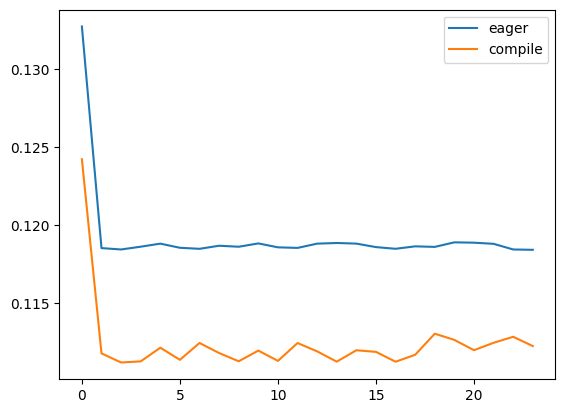

In [12]:
plt.plot(eager_time[1:], label=f"eager")
plt.plot(compile_time[1:], label="compile")
plt.legend(loc="upper right")
plt.show()

## Underpinning Technologies for `torch.compile`

Texts from [PyTorch Official Get-Started](https://pytorch.org/get-started/pytorch-2.0/#pytorch-2x-faster-more-pythonic-and-as-dynamic-as-ever) give a nice summary of the enablers of the `torch.compile`. The graph is extracted from [PyTorch Conference 2022](https://www.youtube.com/watch?v=vbtGZL7IrAw&t=1s)

- `TorchDynamo` captures PyTorch programs safely using Python Frame Evaluation Hooks and is a significant innovation that was a result of 5 years of our R&D into safe graph capture

- `AOTAutograd` overloads PyTorch’s autograd engine as a tracing autodiff for generating ahead-of-time backward traces. It learns how the gradients are derived in eager mode and patch it back to the compile mode (AOT: Ahead of time).

- `PrimTorch` canonicalizes ~2000+ PyTorch operators down to a closed set of ~250 primitive operators that developers can target to build a complete PyTorch backend. This substantially lowers the barrier of writing a PyTorch feature or backend.

- `TorchInductor` is a deep learning compiler that generates fast code for multiple accelerators and backends. For NVIDIA GPUs, it uses OpenAI Triton as a key building block. For CPUs, it generates C++ code. Not compatible with older GPUs other than Volta and Ampere.

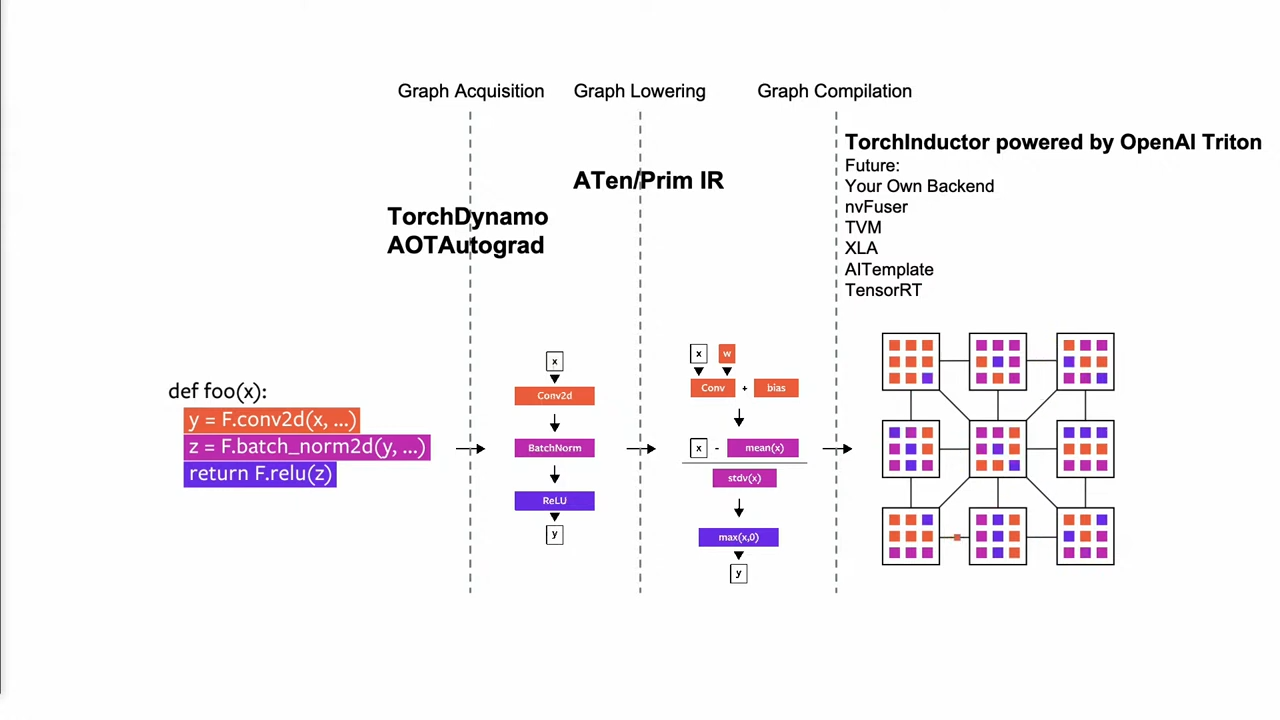


## TorchDynamo and FX Graphs

Eager mode is great because it is easy to understand, debug, and hack.

But at this point, we want to maximize the hardware capacity, so we need to get the graph of the model.

So that we can compile PyTorch components into one single operation.

`torch.fx` is a functional programming library for PyTorch that allows users to define their models as a directed acyclic graph (DAG) of functions.

TorchDynamo JIT compiles arbitrary Python code into [FX graphs](https://pytorch.org/docs/stable/fx.html#torch.fx.Graph), which can then be further compiled.

TorchDynamo hooks into the frame evaluation API (introduced in Python 3.7), reads the bytecode and symbolically indentifies the traces of bytecode.
After it finds the compilable parts, it patches the bytecode and creates a shortcut to the compiled version.

```
#     +------------+        +------------+        +------------+
#     |            | Parser |            |        |            |------running continuously
#     |     PY     |------->|  bytecode  |------->|   CPython  |
#     |            |        |            |        |            |------+
#     +------------+        +------------+        +------------+      |
#                                 |                                   | modified bytecode
#                                 |               +------------+      |
#                                 |               |            |      |
#                                 +-------------> |  Callback  |------+
#                                                 |            |
#                                                 +------------+
```




## Get the FX graph in eager mode

Normally, TorchInductor, another component of torch.compile, further compiles the FX graphs into optimized kernels, but TorchDynamo allows for different backends to be used.
In order to inspect the FX graphs that TorchDynamo outputs, let us create a custom backend that outputs the FX graph and simply returns the graph’s **unoptimized forward method**.

In [13]:
from typing import List
def custom_backend(gm: torch.fx.GraphModule, example_inputs: List[torch.Tensor]):
    print("custom backend called with FX graph:")
    gm.graph.print_tabular()
    return gm.forward

import torch._dynamo
# Reset since we are using a different backend.
torch._dynamo.reset()

opt_model = torch.compile(model, backend=custom_backend)
outputs = opt_model(inputs)

custom backend called with FX graph:
opcode         name                          target                        args                                                    kwargs
-------------  ----------------------------  ----------------------------  ------------------------------------------------------  --------
placeholder    x                             x                             ()                                                      {}
call_module    self_conv_init_0              self_convInit_0               (x,)                                                    {}
call_module    self_down_layers_0_0          self_down_layers_0_0          (self_conv_init_0,)                                     {}
call_module    self_down_layers_0_1_norm1    self_down_layers_0_1_norm1    (self_down_layers_0_0,)                                 {}
call_module    self_down_layers_0_1_act      self_down_layers_0_1_act      (self_down_layers_0_1_norm1,)                           {}
call_module    

## TorchDynamo gives graph(s) from the evaluation

For the blocks that are not compilable, use the eager mode

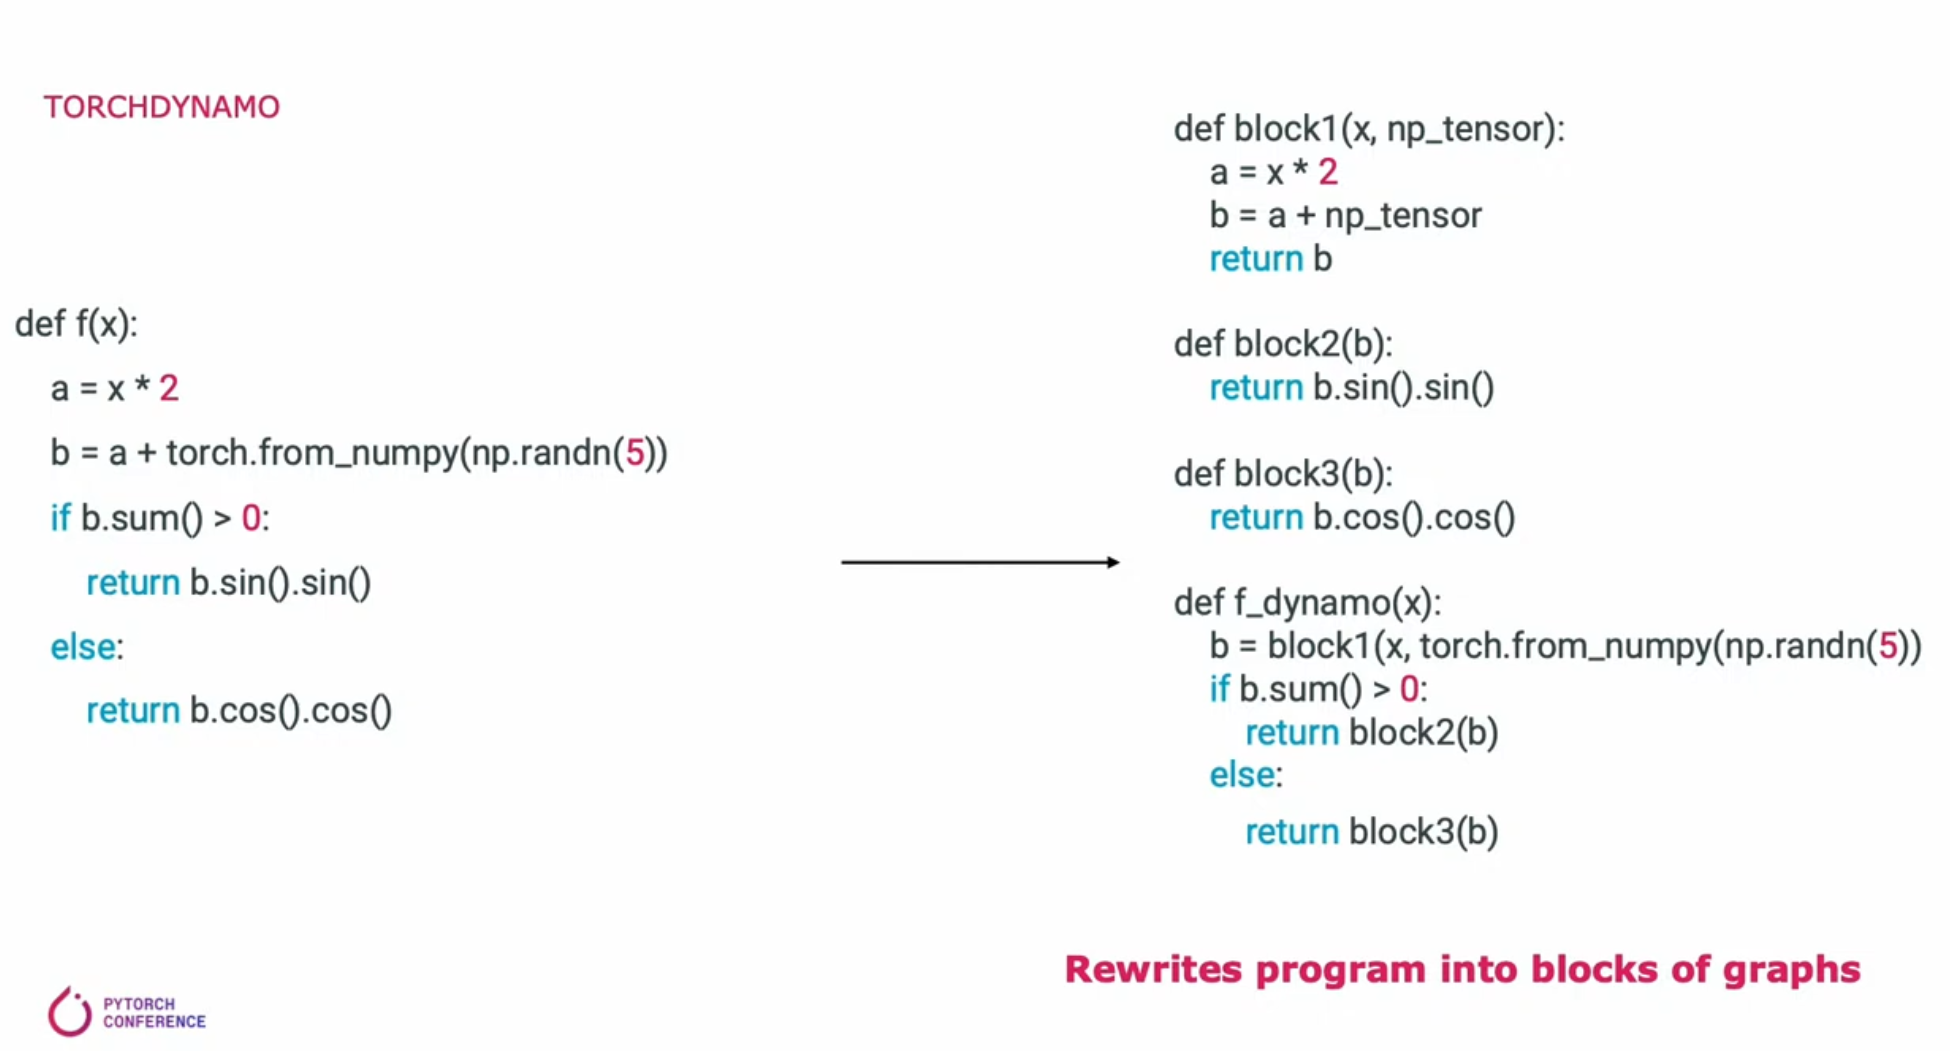

In [14]:
explanation, out_guards, graphs, ops_per_graph, break_reasons, explanation_verbose = torch._dynamo.explain(
    train_opt, model, inputs, labels
)
print(graphs)

[GraphModule(
  (self_convInit_0): Conv3d(1, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  (self_down_layers_0_0): Identity()
  (self_down_layers_0_1_norm1): GroupNorm(8, 8, eps=1e-05, affine=True)
  (self_down_layers_0_1_act): ReLU(inplace=True)
  (self_down_layers_0_1_conv1_0): Conv3d(8, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  (self_down_layers_0_1_norm2): GroupNorm(8, 8, eps=1e-05, affine=True)
  (self_down_layers_0_1_conv2_0): Conv3d(8, 8, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  (self_down_layers_1_0_0): Conv3d(8, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
  (self_down_layers_1_1_norm1): GroupNorm(8, 16, eps=1e-05, affine=True)
  (self_down_layers_1_1_act): ReLU(inplace=True)
  (self_down_layers_1_1_conv1_0): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  (self_down_layers_1_1_norm2): GroupNorm(8, 16, eps=1e

In [15]:
print(explanation_verbose)

Dynamo produced 4 graphs with 3 graph break and 27 ops
 Break reasons: 

1. call_method ListVariable() reverse [] {}
  File "/home/adminn/miniconda3/envs/pt2/lib/python3.8/site-packages/monai/networks/nets/segresnet.py", line 180, in forward
    down_x.reverse()
 
2. Tensor.tolist
  File "/home/adminn/miniconda3/envs/pt2/lib/python3.8/site-packages/monai/losses/dice.py", line 160, in forward
    reduce_axis: List[int] = torch.arange(2, len(input.shape)).tolist()
 
TorchDynamo compilation metrics:
Function                                             Runtimes (s)
---------------------------------------------------  ----------------------------------------------------------------------
convert_frame_assert.<locals>._convert_frame_assert  0.1113, 0.0924, 0.0442, 0.0031, 0.0058, 0.0082, 0.0083, 0.0015, 0.0008
